In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import pickle
import pandas as pd


No protocol specified


# generate true Us

In [2]:
n_subs = 24
n_parcel = 20
n_voxels  = 40
n_tasks = 16


Us = sim.generate_Us(s= n_subs, k = n_parcel, p = n_voxels, type= 'hard')

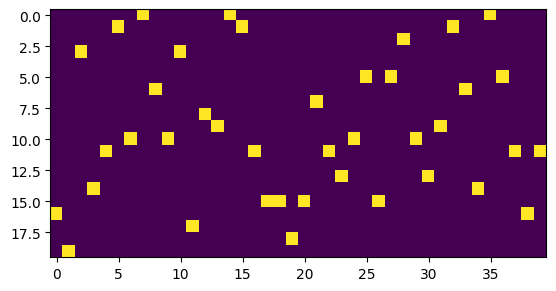

In [3]:
plt.imshow(Us[1])

# Generate Vtrain

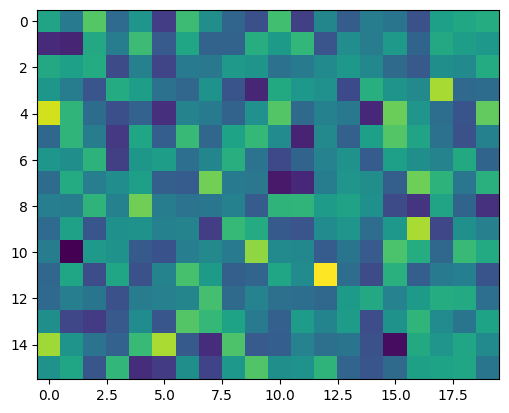

In [4]:
# generate Vs from normal distribution
Vs = np.random.normal(0,1,(n_tasks,n_parcel))

# subtract mean across rows
Vs = Vs - np.mean(Vs, axis=1, keepdims=True)

plt.imshow(Vs)


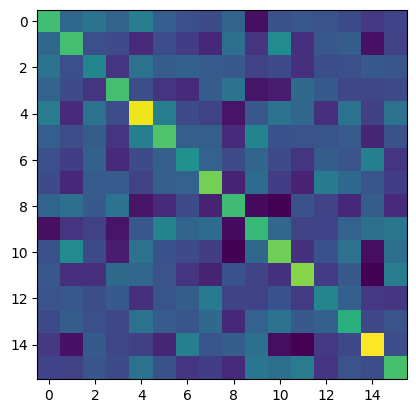

In [5]:
G_rand = Vs @ Vs.T
plt.imshow(G_rand)

# Generate data

In [6]:
# get the data no nooise
y = Vs @ Us

# add noise to data
noise_std = 0.1
noise = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_noisy = y + noise


# Test different methods to estimate Us based on non noisy data

In [7]:
def U_MSE (U_true, U_pred):
    MSE = []
    for subject in range(U_true.shape[0]):
        mse = np.mean((U_true[subject] - U_pred[subject])**2)
        MSE.append(mse)
    return np.mean(MSE)
        


In [8]:
# test different methos
U_hat_ols = sim.estimate_Us_ols(y_noisy, Vs)
U_hat_NNLS = sim.estimate_Us_NNLS(y_noisy, Vs)
U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_noisy, Vs)

In [9]:
OLS_MSE = U_MSE(Us, U_hat_ols)
NNLS_MSE = U_MSE(Us, U_hat_NNLS)
L1_MSE = U_MSE(Us, U_hat_l1)

print(f"OLS MSE: {OLS_MSE}")
print(f"NNLS MSE: {NNLS_MSE}")
print(f"L1 MSE: {L1_MSE}")



OLS MSE: 0.01202699722896212
NNLS MSE: 0.00831486339844061
L1 MSE: 0.0008858043286905227


# make test data and Vs

In [10]:
# generate Vs from normal distribution
Vt = np.random.normal(0,1,(n_tasks,n_parcel))

# subtract mean across rows
Vt = Vt - np.mean(Vt, axis=1, keepdims=True)

# get the data no nooise
yt = Vt @ Us

# add noise to data
noise_std = 0.1
noise_t = np.random.normal(loc=0.0, scale=noise_std, size=y.shape)
y_t_noisy = yt + noise

# make into tensors
y_t_noisy_pt = pt.tensor(y_t_noisy, dtype=pt.float32)
Vt_pt = pt.tensor(Vt, dtype=pt.float32)
U_true_pt = pt.tensor(Us, dtype=pt.float32)

# Evaluate different lists of V on U_MSE

In [119]:
# make a function that will generate a list 
def evaluate_fixed_task_subset(U_true, Vs, subset_size=8, n_samples=250):
    n_tasks, n_parcels = Vs.shape
    results = {'eigenvalues':[],'OLS':[],'NNLS': [], 'L1': [],'L2' : [],'eig_sum':[],'log_det':[],'min_est':[],'cos_err':[]}

    # Generate fixed-size subsets of tasks
    for _ in range(n_samples):
        print(_)
        # Randomly select a fixed number of tasks
        task_subset_indices = np.random.choice(n_tasks, subset_size, replace=True)
        V_subset = Vs[task_subset_indices, :]
        
        #subtract mean across rows
        V_subset = V_subset - np.mean(V_subset, axis=0)

        G = V_subset @ V_subset.T

        l, _ = eigh(G)
        l = l[::-1]  
        l = l[:-1]  # Remove the last eigenvalue (should be zero after centering)
    
        l[l < 0] = 0  # Remove negative eigenvalues
        results['eig_sum'].append(np.sum(l))
        results['log_det'].append(np.sum(np.log(l + 1e-10)))  # Add small value to avoid log(0)
        results['min_est'].append(np.sum(1 / (l + 1e-10)))
        results['eigenvalues'].append(l)

        # generate data
        y_subset =  V_subset @ U_true

        # Estimate Us for each method
        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        U_hat_NNLS = sim.estimate_Us_NNLS(y_subset, V_subset)
        U_hat_l1 = sim.estimate_Us_NNLS_lasso(y_subset, V_subset)
        U_hat_l2 = sim.estimate_Us_NNLS_ridge(y_subset, V_subset)

        # Calculate MSE and record
        results['OLS'].append(U_MSE(U_true, U_hat_ols))
        results['NNLS'].append(U_MSE(U_true, U_hat_NNLS))
        results['L1'].append(U_MSE(U_true, U_hat_l1))
        results['L2'].append(U_MSE(U_true, U_hat_l2))

        U_hat_ols_pt = pt.tensor(U_hat_ols, dtype=pt.float32)

        # Calculate cosine similarity between true and estimated Us
        cor_err = ev.coserr(y_t_noisy_pt,Vt_pt,U_hat_ols_pt).mean().numpy()
        cor_err = float(cor_err)
        results['cos_err'].append(cor_err)

    results_df = pd.DataFrame(results)
    return results_df

In [120]:
subset_size = 8  
n_samples = 25
results_random = evaluate_fixed_task_subset(Us, Vs, subset_size=subset_size, n_samples=n_samples)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


<Axes: xlabel='min_est', ylabel='log_det'>

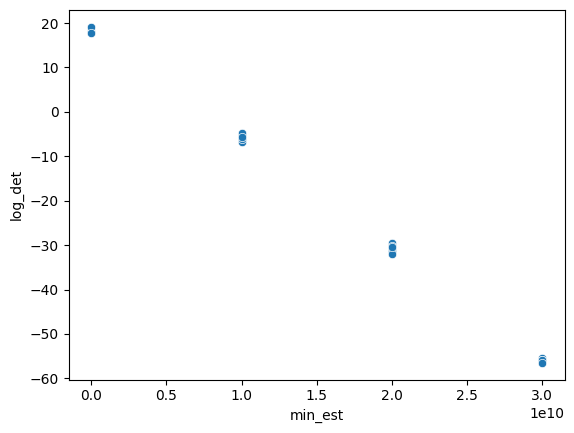

In [42]:
sns.scatterplot(x='min_est', y='log_det', data=results_random)


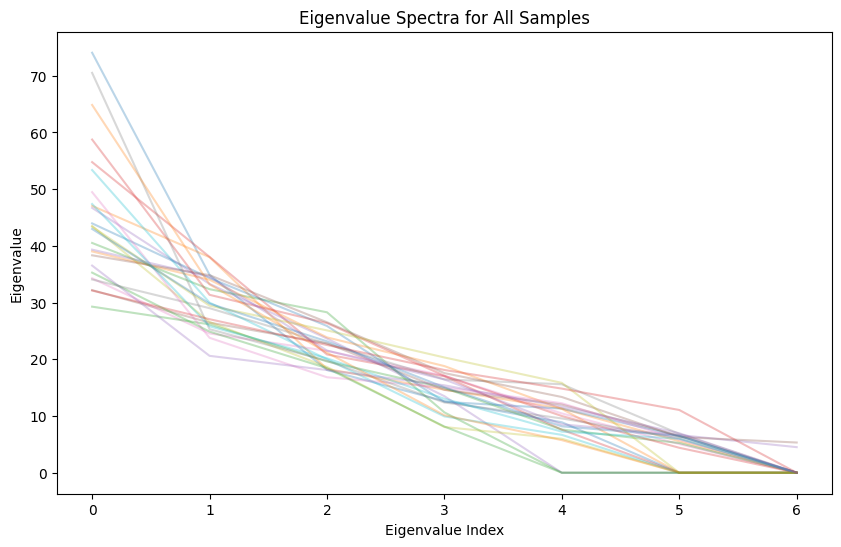

In [121]:
eigenvalues_array = np.array(results_random['eigenvalues'].tolist())
plt.figure(figsize=(10, 6))
for i in range(eigenvalues_array.shape[0]):
    plt.plot(eigenvalues_array[i], alpha=0.3)

plt.title('Eigenvalue Spectra for All Samples')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.show()

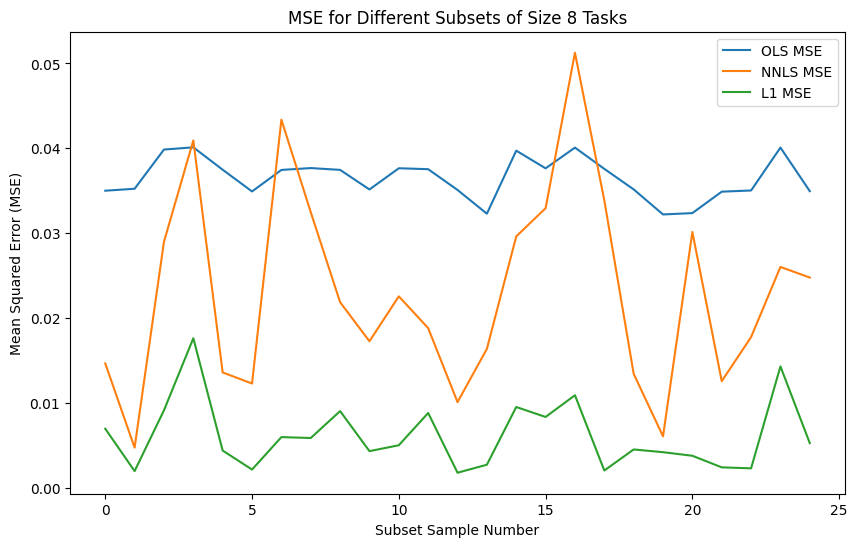

In [43]:
methods = ['OLS', 'NNLS', 'L1']

# Plot each method separately
plt.figure(figsize=(10, 6))
for method in methods:
    sns.lineplot(x=results_random.index, y=results_random[method], label=f"{method} MSE")

plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [44]:
methods = ['OLS', 'NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

correlations_df = pd.DataFrame(index=eigen_metrics, columns=methods)
for metric in eigen_metrics:
    for method in methods:
        correlations_df.loc[metric, method] = results_random[metric].corr(results_random[method])

print(correlations_df)

              OLS      NNLS        L1
eig_sum  0.022414 -0.045735  0.124383
log_det -0.997657 -0.646363 -0.750587
min_est  0.998367  0.641697   0.75056


In [47]:
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

cos_err_correlations = pd.Series(index=eigen_metrics, dtype=float)

# Compute the correlations
for metric in eigen_metrics:
    corr = results_random['cos_err'].corr(results_random[metric])
    cos_err_correlations[metric] = corr

print("Correlations between cos_err and eigen metrics:")
print(cos_err_correlations)


Correlations between cos_err and eigen metrics:
eig_sum    0.243996
log_det   -0.877038
min_est    0.881468
dtype: float64


# construct Vs with tasks with no correlation

In [123]:
def gram_schmidt(V):
    """ Apply Gram-Schmidt process to matrix V. """
    Q = np.zeros_like(V)
    for i in range(V.shape[0]):
        # Start with the i-th row of A
        q = V[i, :]
        
        # Subtract the projection of q onto the previous rows
        for j in range(0, i):
            q = q - np.dot(Q[j, :], V[i, :]) * Q[j, :]

        # Normalize q to have unit norm
        Q[i, :] = q / np.linalg.norm(q)

    return Q


In [124]:
V_random = np.random.randn(n_tasks, n_parcel)
Vs_orthogonal = gram_schmidt(V_random)
Vs_orthogonal = Vs_orthogonal + np.random.normal(0, 0.01, (n_tasks, n_parcel))


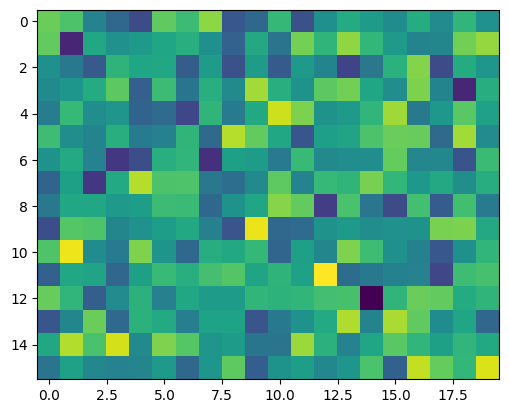

In [125]:
plt.imshow(Vs_orthogonal)

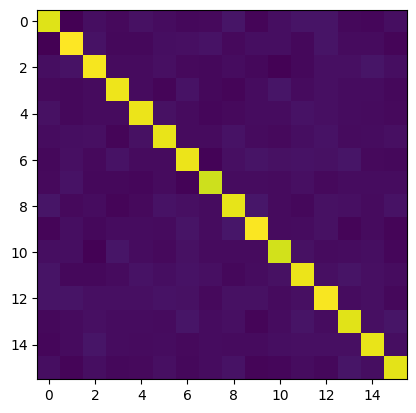

In [126]:
# add diff constants to each row in Vs_orthogonal
G_orthogonal = Vs_orthogonal @ Vs_orthogonal.T
plt.imshow(G_orthogonal)

In [127]:
results_uncorr = evaluate_fixed_task_subset(Us, Vs_orthogonal, subset_size=subset_size, n_samples=n_samples)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


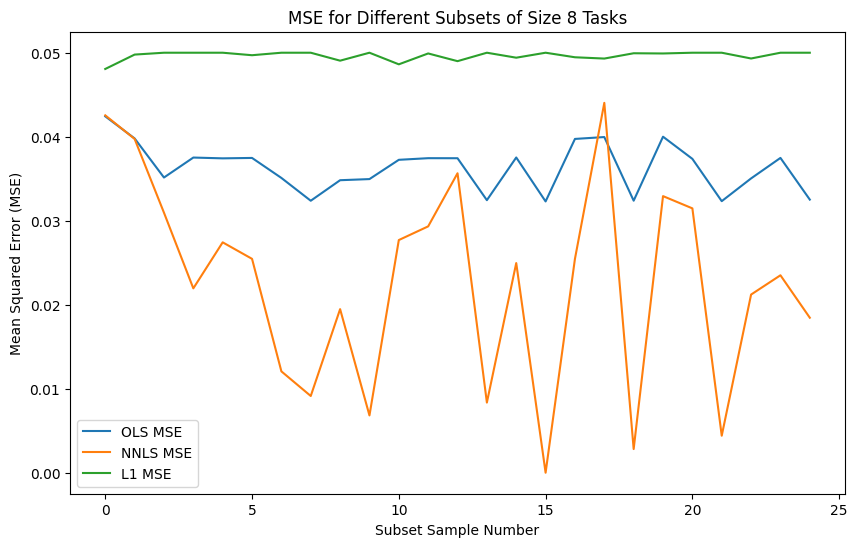

In [139]:
methods = ['OLS', 'NNLS', 'L1']

# Plot each method separately
plt.figure(figsize=(10, 6))
for method in methods:
    sns.lineplot(x=results_uncorr.index, y=results_uncorr[method], label=f"{method} MSE")

plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [140]:
methods = ['OLS', 'NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

correlations_df = pd.DataFrame(index=eigen_metrics, columns=methods)
for metric in eigen_metrics:
    for method in methods:
        correlations_df.loc[metric, method] = results_uncorr[metric].corr(results_uncorr[method])

print(correlations_df)

              OLS      NNLS        L1
eig_sum -0.970318  -0.85287  0.455536
log_det -0.999309 -0.867839  0.516622
min_est  0.999363  0.867825 -0.516971


In [141]:
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

cos_err_correlations = pd.Series(index=eigen_metrics, dtype=float)

# Compute the correlations
for metric in eigen_metrics:
    corr = results_uncorr['cos_err'].corr(results_uncorr[metric])
    cos_err_correlations[metric] = corr

print("Correlations between cos_err and eigen metrics:")
print(cos_err_correlations)


Correlations between cos_err and eigen metrics:
eig_sum   -0.935673
log_det   -0.917819
min_est    0.917123
dtype: float64


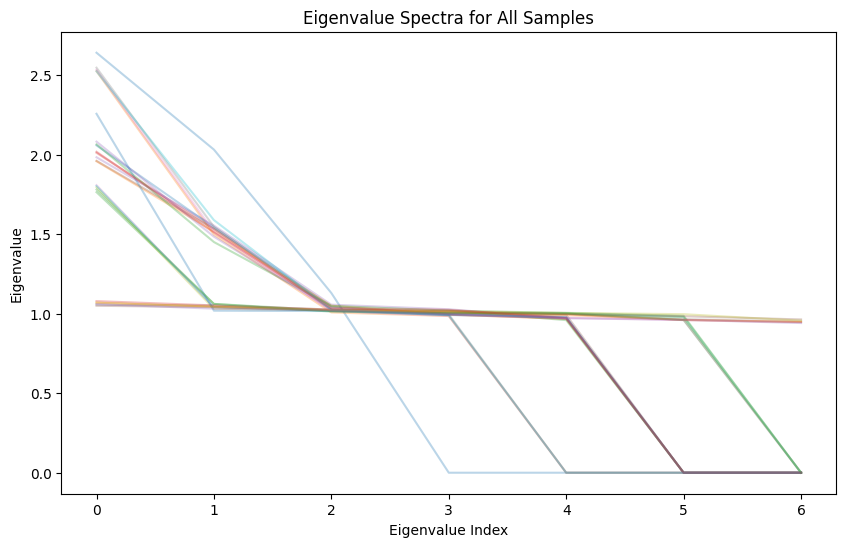

In [142]:
eigenvalues_array = np.array(results_uncorr['eigenvalues'].tolist())
plt.figure(figsize=(10, 6))
for i in range(eigenvalues_array.shape[0]):
    plt.plot(eigenvalues_array[i], alpha=0.3)

plt.title('Eigenvalue Spectra for All Samples')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.show()

# constrcut Vs with tasks with big correlation

In [132]:
base_pattern = np.random.randn(1, n_parcel) * 10 
Vs_corr = np.tile(base_pattern, (n_tasks, 1)) 
Vs_corr += 0.1 * np.random.randn(n_tasks, n_parcel)

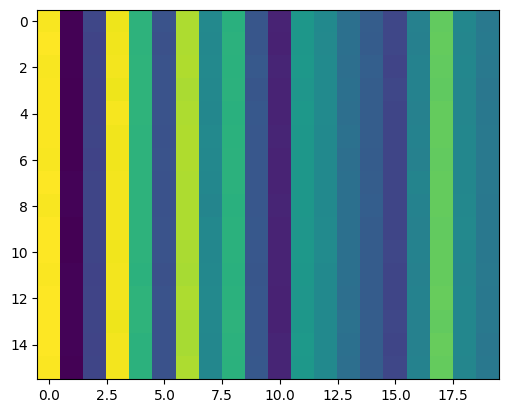

In [133]:
plt.imshow(Vs_corr)

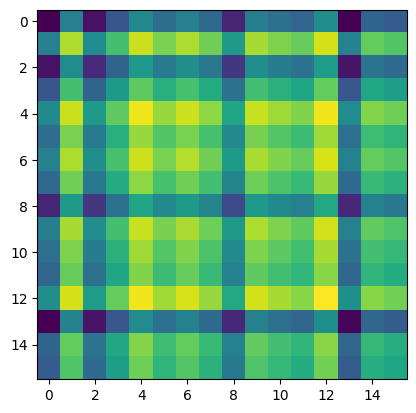

In [134]:
G_corr = Vs_corr @ Vs_corr.T 
plt.imshow(G_corr)


In [135]:
results_corr = evaluate_fixed_task_subset(Us, Vs_corr, subset_size=subset_size, n_samples=n_samples)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


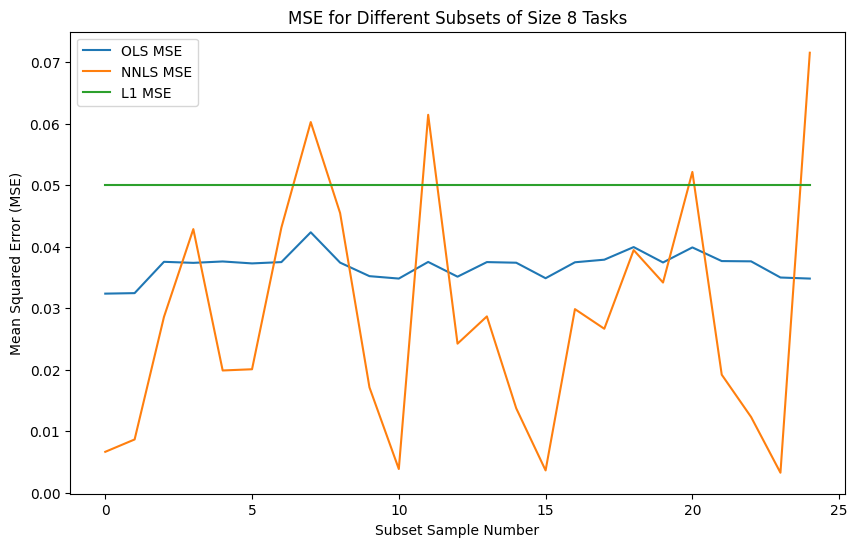

In [136]:
methods = ['OLS', 'NNLS', 'L1']

# Plot each method separately
plt.figure(figsize=(10, 6))
for method in methods:
    sns.lineplot(x=results_corr.index, y=results_corr[method], label=f"{method} MSE")

plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [137]:
methods = ['OLS', 'NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

correlations_df = pd.DataFrame(index=eigen_metrics, columns=methods)
for metric in eigen_metrics:
    for method in methods:
        correlations_df.loc[metric, method] = results_corr[metric].corr(results_corr[method])

print(correlations_df)

              OLS      NNLS   L1
eig_sum -0.334421 -0.101064  NaN
log_det -0.996336 -0.564454  NaN
min_est  0.997907  0.563623  NaN


In [138]:
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

cos_err_correlations = pd.Series(index=eigen_metrics, dtype=float)

# Compute the correlations
for metric in eigen_metrics:
    corr = results_corr['cos_err'].corr(results_corr[metric])
    cos_err_correlations[metric] = corr

print("Correlations between cos_err and eigen metrics:")
print(cos_err_correlations)


Correlations between cos_err and eigen metrics:
eig_sum   -0.261148
log_det   -0.852990
min_est    0.854983
dtype: float64


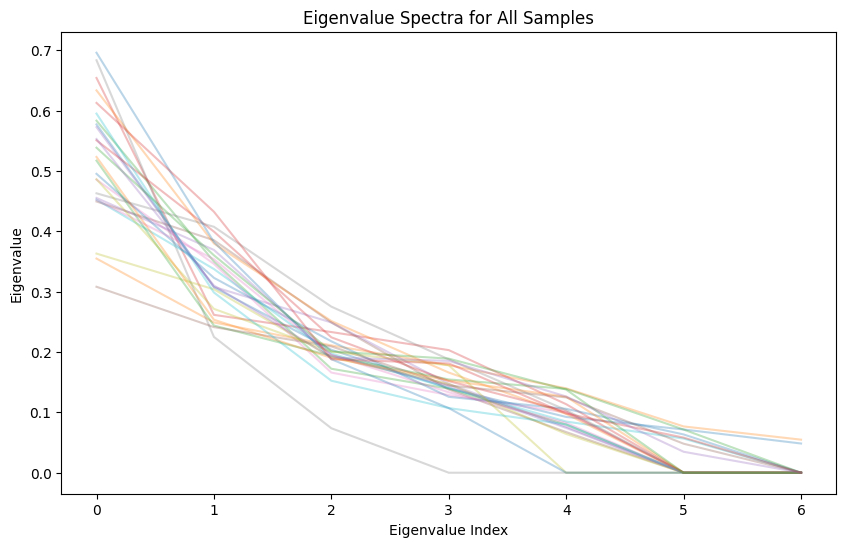

In [165]:
eigenvalues_array = np.array(results_corr['eigenvalues'].tolist())
plt.figure(figsize=(10, 6))
for i in range(eigenvalues_array.shape[0]):
    plt.plot(eigenvalues_array[i], alpha=0.3)

plt.title('Eigenvalue Spectra for All Samples')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.show()

# Load MDTB G matrix

In [144]:
import os
dir = 'Y:/data/FunctionalFusion/MDTB'

if not os.path.exists(dir):
    dir = '/cifs/diedrichsen/data/FunctionalFusion/MDTB'


MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1[np.isnan(data_mdtb_s1)] = 0


In [145]:
task_names = info_mdtb_1['cond_name'].unique()
print(task_names)

['NoGo' 'Go' 'ToM' 'VideoAct' 'VideoKnots' 'UnpleasantScenes'
 'PleasantScenes' 'Math' 'DigitJudgement' 'CheckerBoard' 'SadFaces'
 'HappyFaces' 'IntervalTiming' 'MotorImagery' 'FingerSimple' 'FingerSeq'
 'Verbal0Back' 'Verbal2Back' 'Object0Back' 'Object2Back'
 'SpatialNavigation' 'StroopIncon' 'StroopCon' 'VerbGen' 'WordRead'
 'VisualSearchSmall' 'VisualSearchMed' 'VisualSearchLarge' 'rest']


In [146]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

<Axes: >

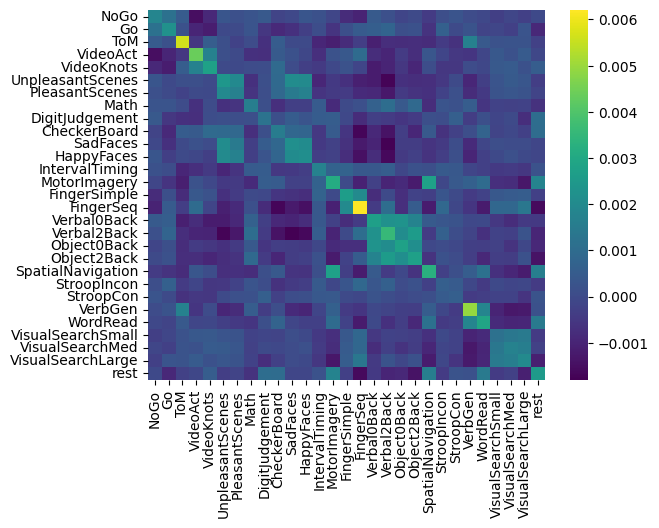

In [147]:
Gs_list = []
E_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

tensor(14.9931)


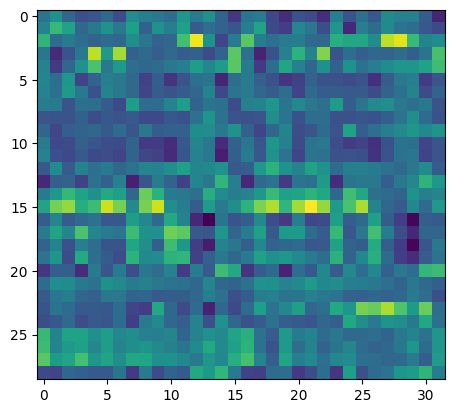

In [148]:
# mdtb vs based on HBP
model_dir = 'Y:/data/Cerebellum/ProbabilisticParcellationModel/Models'
if not os.path.exists(model_dir):
    model_dir = '/cifs/diedrichsen/data/Cerebellum/ProbabilisticParcellationModel/Models'
    
model_name = f'/Models_03/NettekovenSym32_space-MNISymC2'
fname = model_dir + model_name
with open(fname + '.pickle', 'rb') as file:
        full_model = pickle.load(file)[0]

# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
print(mdtb_1_emission.kappa)
mdtb_1_Vs = mdtb_1_emission.V

# make np array
mdtb_1_Vs = np.array(mdtb_1_Vs)

plt.imshow(mdtb_1_Vs)

In [149]:
from sklearn.decomposition import PCA
from factor_analyzer import Rotator
n_parcels = 20
# Perform PCA
pca = PCA(n_components=n_parcels)
pca.fit(G_individuals_averaged)
V = pca.components_.T  

# Apply Varimax rotation
rotator = Rotator(method='varimax')
V_rotated = rotator.fit_transform(V)

# Compute the new G
G_rotated = V_rotated @ V_rotated.T


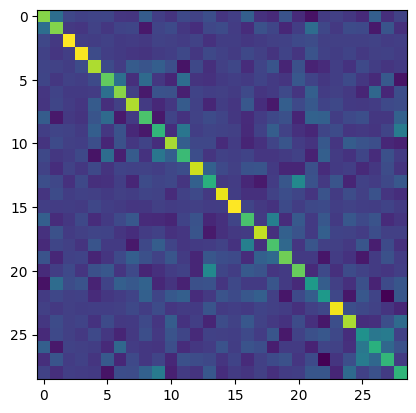

In [150]:
plt.imshow(G_rotated)

In [151]:
subset_size = 8
n_samples = 25

results_mdtb = evaluate_fixed_task_subset(Us, V_rotated, subset_size=subset_size, n_samples=n_samples)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


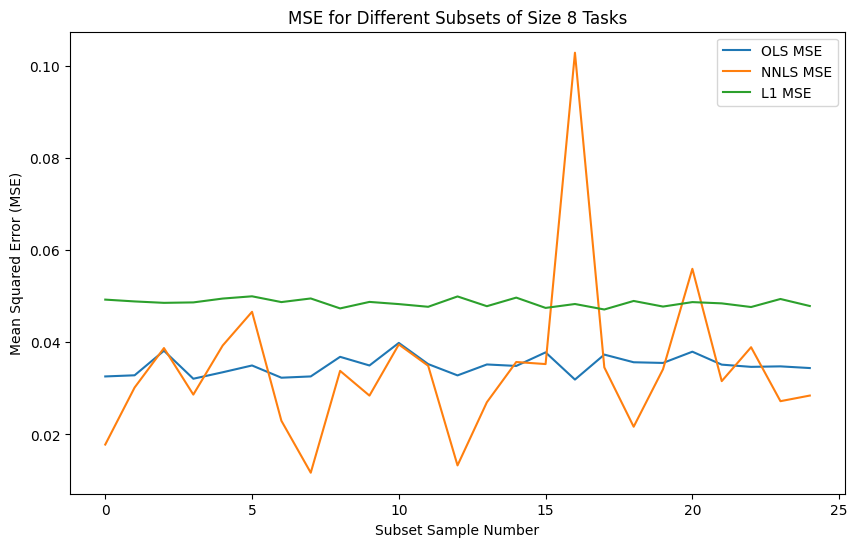

In [152]:
methods = ['OLS', 'NNLS', 'L1']

# Plot each method separately
plt.figure(figsize=(10, 6))
for method in methods:
    sns.lineplot(x=results_mdtb.index, y=results_mdtb[method], label=f"{method} MSE")

plt.xlabel('Subset Sample Number')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE for Different Subsets of Size {subset_size} Tasks')
plt.legend()
plt.show()

In [153]:
methods = ['OLS', 'NNLS', 'L1']
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

correlations_df = pd.DataFrame(index=eigen_metrics, columns=methods)
for metric in eigen_metrics:
    for method in methods:
        correlations_df.loc[metric, method] = results_mdtb[metric].corr(results_mdtb[method])

print(correlations_df)

              OLS      NNLS        L1
eig_sum -0.184274  0.057556 -0.327697
log_det -0.976568 -0.122988  0.485478
min_est  0.980252  0.129275 -0.499973


In [154]:
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

cos_err_correlations = pd.Series(index=eigen_metrics, dtype=float)

# Compute the correlations
for metric in eigen_metrics:
    corr = results_mdtb['cos_err'].corr(results_mdtb[metric])
    cos_err_correlations[metric] = corr

print("Correlations between cos_err and eigen metrics:")
print(cos_err_correlations)


Correlations between cos_err and eigen metrics:
eig_sum   -0.179985
log_det   -0.912744
min_est    0.915964
dtype: float64


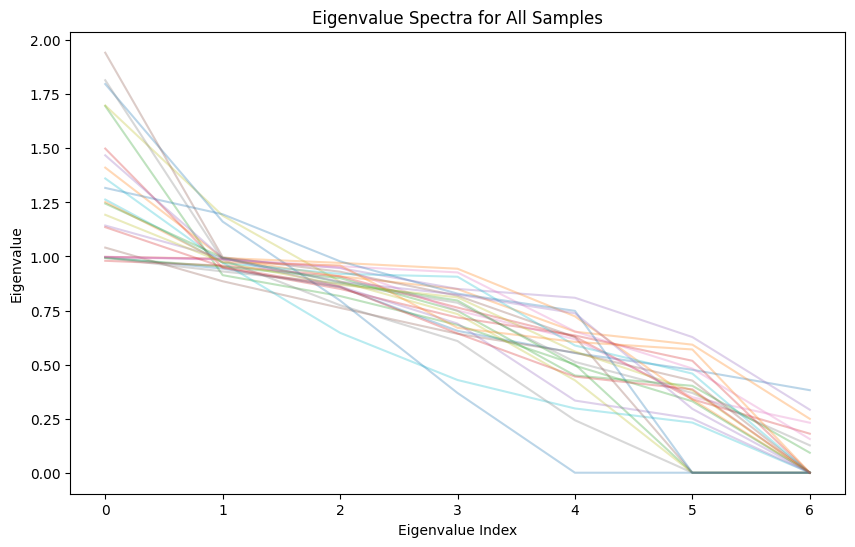

In [155]:
eigenvalues_array = np.array(results_mdtb['eigenvalues'].tolist())
plt.figure(figsize=(10, 6))
for i in range(eigenvalues_array.shape[0]):
    plt.plot(eigenvalues_array[i], alpha=0.3)

plt.title('Eigenvalue Spectra for All Samples')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.show()

# test on actual data

In [108]:
dir = 'Y:/data/FunctionalFusion/MDTB'
if not os.path.exists(dir):
    dir = '/cifs/diedrichsen/data/FunctionalFusion/MDTB'

In [109]:
MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0

In [110]:
MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

In [111]:
MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondRun')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0

In [112]:
MDTB_dataset = DataSetMDTB(dir=dir)
data_mdtb_s2_All,info_mdtb_2_All  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_All[np.isnan(data_mdtb_s2_All)] = 0

# Get G matrix for s1 and decompose into Vs

In [83]:
task_names = info_mdtb_1_run['cond_name'].unique()
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


# Perform PCA
pca = PCA(n_components=n_parcels)
pca.fit(G_individuals_averaged)
V = pca.components_.T  

# Apply Varimax rotation
rotator = Rotator(method='varimax')
V_rotated = rotator.fit_transform(V)

# Compute the new G
G_rotated = V_rotated @ V_rotated.T


# Get G matrix for s2 and decompose into Vs

In [96]:
task_names = info_mdtb_2_run['cond_name'].unique()
cond_vec = np.tile(np.arange(1, 32 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 32)

Gs_list = []
E_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s2_run[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


# Perform PCA
pca = PCA(n_components=n_parcels)
pca.fit(G_individuals_averaged)
V = pca.components_.T  

# Apply Varimax rotation
rotator = Rotator(method='varimax')
V_rotated_test = rotator.fit_transform(V)

# Compute the new G
G_rotated = V_rotated @ V_rotated.T


In [156]:
# make a function that will generate a list 
def cos_error_mdtb(vtrain,ytest, vtest, subset_size=8, n_samples=250):
    n_tasks, n_parcels = Vs.shape
    results = {'eigenvalues':[],'eig_sum':[],'log_det':[],'min_est':[],'cos_err':[]}

    # Generate fixed-size subsets of tasks
    for _ in range(n_samples):
        print(_)
        # Randomly select a fixed number of tasks
        task_subset_indices = np.random.choice(n_tasks, subset_size, replace=True)
        V_train_subset = vtrain[task_subset_indices, :]
        
        #subtract mean across rows
        V_train_subset = V_train_subset - np.mean(V_train_subset, axis=0)

        G = V_train_subset @ V_train_subset.T

        l, _ = eigh(G)
        l = l[::-1]  
        l = l[:-1]  # Remove the last eigenvalue (should be zero after centering)
    
        l[l < 0] = 0  # Remove negative eigenvalues
        results['eig_sum'].append(np.sum(l))
        results['log_det'].append(np.sum(np.log(l + 1e-10)))  # Add small value to avoid log(0)
        results['min_est'].append(np.sum(1 / (l + 1e-10)))
        results['eigenvalues'].append(l)

    
        ytrain  = data_mdtb_s1_All[:,task_subset_indices,:]

        U_hat_ols = sim.estimate_Us_ols(ytrain, V_train_subset)
        U_hat_ols_pt = pt.tensor(U_hat_ols, dtype=pt.float32)
        ytest  = pt.tensor(ytest, dtype=pt.float32)
        vtest = pt.tensor(vtest, dtype=pt.float32)

        
        cor_err = ev.coserr(ytest,vtest,U_hat_ols_pt).mean().numpy()
        cor_err = float(cor_err)
        results['cos_err'].append(cor_err)

    results_df = pd.DataFrame(results)
    return results_df

In [160]:
results_fmri  = cos_error_mdtb(V_rotated,data_mdtb_s2_All,V_rotated_test, subset_size=subset_size, n_samples=25)

0
1


/tmp/ipykernel_73871/1887273886.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ytest  = pt.tensor(ytest, dtype=pt.float32)
/tmp/ipykernel_73871/1887273886.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  vtest = pt.tensor(vtest, dtype=pt.float32)


2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


In [163]:
eigen_metrics = ['eig_sum', 'log_det', 'min_est']

cos_err_correlations = pd.Series(index=eigen_metrics, dtype=float)

# Compute the correlations
for metric in eigen_metrics:
    corr = results_fmri['cos_err'].corr(results_fmri[metric])
    cos_err_correlations[metric] = corr

print("Correlations between cos_err and eigen metrics:")
print(cos_err_correlations)


Correlations between cos_err and eigen metrics:
eig_sum   -0.258191
log_det   -0.576225
min_est    0.574978
dtype: float64


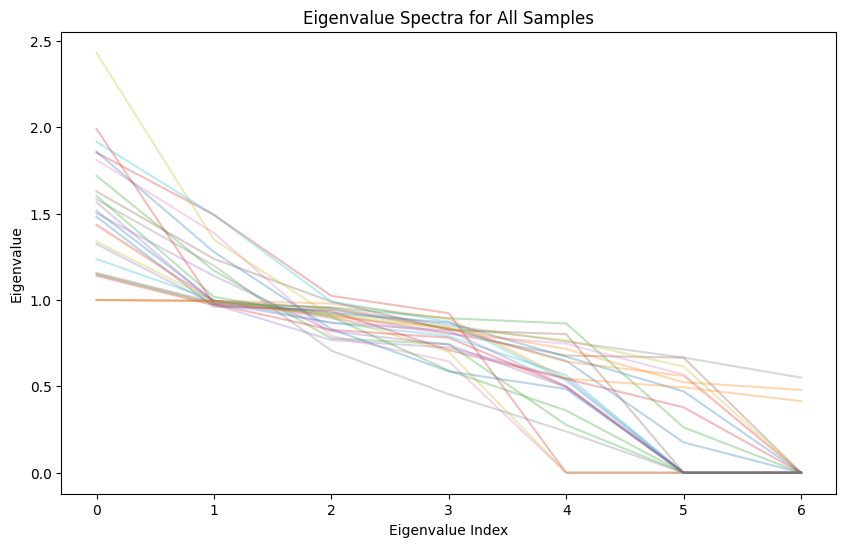

In [164]:
eigenvalues_array = np.array(results_fmri['eigenvalues'].tolist())
plt.figure(figsize=(10, 6))
for i in range(eigenvalues_array.shape[0]):
    plt.plot(eigenvalues_array[i], alpha=0.3)

plt.title('Eigenvalue Spectra for All Samples')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.show()